# Word2Vec Pipeline (Pipeline 1)
**Namratha Shetty · L00196930 · ATU**

## Setup

In [ ]:
!pip -q install gensim scikit-learn pandas numpy tqdm kagglehub
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 51.1 MB/s eta 0:00:00
Dependencies installed.


## Config

In [ ]:
SEED          = 42
CLEAN_MODE    = 'minimal'   # 'minimal' = mask block-ids + timestamps + tidy whitespace (honest to AnyLog)
                            # 'aggressive' = also strip numbers/punctuation
SAMPLE_BLOCKS   = 300       # keep this many WHOLE blocks (complete traces). Raise once it runs.
MIN_BLOCK_LINES = 6         # ignore blocks with fewer lines — need multi-line traces to reconstruct
MAX_LEN       = 64          # BERT token cap per log line (HDFS lines are short)
BATCH_SIZE    = 32
PCA_DIM       = 50          # reduce 768-d BERT vectors before fusing with time
TIME_UNIT     = 60.0        # seconds per unit in the time feature (60 = distances measured in minutes)
EPS           = 1.5         # DBSCAN radius — best cell of the Section 9 sweep
MIN_SAMPLES   = 4           # DBSCAN min points for a core (blocks have >= MIN_BLOCK_LINES lines)
TIME_WEIGHT   = 2.0         # relative weight of time vs meaning — best cell of the Section 9 sweep
# grids for the sensitivity sweep (Section 9) — centred on the optimum, probing beyond it,
# and keeping time_weight=0 as the meaning-only baseline
EPS_GRID         = [1.4, 1.5, 1.6, 1.8, 2.0]
TIME_WEIGHT_GRID = [0.0, 1.0, 2.0, 3.0, 5.0]

import numpy as np, random
random.seed(SEED); np.random.seed(SEED)
print('Config set. CLEAN_MODE =', CLEAN_MODE, '| SAMPLE_BLOCKS =', SAMPLE_BLOCKS)

Config set. CLEAN_MODE = minimal | SAMPLE_BLOCKS = 300


## Dataset

In [ ]:
import os, glob
DATA_DIR = None
try:
    import kagglehub
    DATA_DIR = kagglehub.dataset_download('ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data')
    print('Downloaded to:', DATA_DIR, '\n')
except Exception as e:
    print('kagglehub download failed:', e)
    print('--> Use the manual upload cell below instead.')

def show_tree(root):
    print('Files in the dataset:')
    print('-'*70)
    for f in sorted(glob.glob(os.path.join(root, '**', '*'), recursive=True)):
        if os.path.isfile(f):
            mb = os.path.getsize(f)/1e6
            print(f'  {mb:8.2f} MB   {os.path.relpath(f, root)}')
    print('-'*70)

if DATA_DIR:
    show_tree(DATA_DIR)

100%|██████████| 1.55G/1.55G [00:32<00:00, 50.9MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/versions/3 

Files in the dataset:
----------------------------------------------------------------------
      0.29 MB   HDFS_2k/HDFS_2k.log
      0.41 MB   HDFS_2k/HDFS_2k.log_structured.csv
      0.00 MB   HDFS_2k/HDFS_2k.log_templates.csv
   1577.98 MB   HDFS_v1/HDFS.log
      0.00 MB   HDFS_v1/README.md
     53.10 MB   HDFS_v1/preprocessed/Event_occurrence_matrix.csv
    125.41 MB   HDFS_v1/preprocessed/Event_traces.csv
      0.00 MB   HDFS_v1/preprocessed/HDFS.log_templates.csv
     52.91 MB   HDFS_v1/preprocessed/HDFS.npz
     18.64 MB   HDFS_v1/preprocessed/anomaly_label.csv
      0.00 MB   HDFS_v2/README.md
    697.98 MB   HDFS_v2/node_logs/hadoop-hdfs-datanode-mesos-01.log
    409.90 MB   HDFS_v2/node_logs/hadoop-hdfs-datanode-mesos-02.log
    444.90 MB   HDFS_v2/node_logs/hadoop-hdfs-datanode-mesos-03.log
    377.42 MB   HDFS_v2/node_logs/hadoop-hdfs-datanode-mesos-05.log

## Load

In [ ]:
import pandas as pd, glob, os
assert DATA_DIR is not None, 'Set DATA_DIR first (run the download or manual-upload cell).'

def find_files(patterns, exclude=('anomaly_label',)):
    hits = []
    for p in patterns:
        for h in glob.glob(os.path.join(DATA_DIR, '**', p), recursive=True):
            base = os.path.basename(h).lower()
            if os.path.isfile(h) and not any(x in base for x in exclude):
                hits.append(h)
    return sorted(set(hits), key=lambda f: -os.path.getsize(f))   # largest first

structured = find_files(['*log_structured*.csv', '*structured*.csv'])
raw_logs   = find_files(['HDFS.log', '*.log'])
def mb(f): return f'{os.path.getsize(f)/1e6:.1f} MB'
print('structured CSVs:', [(os.path.basename(f), mb(f)) for f in structured])
print('raw logs       :', [(os.path.basename(f), mb(f)) for f in raw_logs[:5]], '...')

# IMPORTANT: use the benchmark HDFS_v1/HDFS.log (block-per-trace ground truth).
# Do NOT just take the largest file — the HDFS_v2 node/namenode logs are bigger but their
# block mentions span days with identical templates, so they are NOT clean traces.
v1 = [f for f in raw_logs if os.path.basename(f) == 'HDFS.log' and 'v2' not in f.lower()]
big_structured = [f for f in structured if os.path.getsize(f)/1e6 > 5]
src = (v1 or big_structured or structured or raw_logs)
src = src[0] if src else None
assert src, 'No HDFS log/CSV found (anomaly_label.csv is NOT a log). Check the file list in Section 1.'

if os.path.getsize(src)/1e6 < 5:
    print('\n*** WARNING: chosen file is <5 MB — this looks like the 2k SAMPLE.')
    print('    The sample has ~1 line per block and CANNOT support trace reconstruction.')
    print('    Download the FULL HDFS.log (~1.5 GB) and re-run. ***')

if src.endswith('.csv'):
    df = pd.read_csv(src)
else:
    with open(src, 'r', errors='ignore') as f:
        df = pd.DataFrame({'Content': [ln.rstrip('\n') for ln in f if ln.strip()]})

print('\nUsing:', os.path.basename(src), '|', mb(src), '| shape:', df.shape)
display(df.head())

structured CSVs: [('HDFS_2k.log_structured.csv', '0.4 MB')]
raw logs       : [('hadoop-hdfs-namenode-mesos-01.log', '5420.5 MB'), ('HDFS.log', '1578.0 MB'), ('hadoop-hdfs-datanode-mesos-01.log', '698.0 MB'), ('hadoop-hdfs-datanode-mesos-18.log', '458.3 MB'), ('hadoop-hdfs-datanode-mesos-19.log', '449.6 MB')] ...

Using: HDFS.log | 1578.0 MB | shape: (11175629, 1)


,Content
0,081109 203518 143 INFO dfs.DataNode$DataXceive...
1,081109 203518 35 INFO dfs.FSNamesystem: BLOCK*...
2,081109 203519 143 INFO dfs.DataNode$DataXceive...
3,081109 203519 145 INFO dfs.DataNode$DataXceive...
4,081109 203519 145 INFO dfs.DataNode$PacketResp...


## Sampling

In [ ]:
import re, numpy as np

def find_col(cands):
    low = {c.lower(): c for c in df.columns}
    for cand in cands:
        for lc, orig in low.items():
            if cand in lc: return orig
    return None

msg_col  = find_col(['content','message','log']) or df.columns[0]
date_col = find_col(['date'])
time_col = find_col(['time'])
print('message column:', msg_col, '| date:', date_col, '| time:', time_col)

work = pd.DataFrame()
work['message'] = df[msg_col].astype(str)

# --- GROUND TRUTH: the block id, extracted BEFORE cleaning ---
work['true_block'] = work['message'].str.extract(r'(blk_-?\d+)', expand=False)
work = work[work['true_block'].notna()].reset_index(drop=True)

# --- timestamp in SECONDS (real time, parsed properly — not a concatenated number) ---
def to_seconds(date_s, time_s):
    dt = pd.to_datetime(date_s.str.zfill(6) + time_s.str.zfill(6),
                        format='%y%m%d%H%M%S', errors='coerce')
    return (dt - dt.min()).dt.total_seconds()

if date_col and time_col:
    work['t'] = to_seconds(df.loc[work.index, date_col].astype(str),
                           df.loc[work.index, time_col].astype(str)).values
else:
    # raw HDFS_v1 lines start with 'yymmdd HHMMSS', e.g. '081109 203615 148 INFO ...'
    ts = work['message'].str.extract(r'^(\d{6})\s+(\d{6})')
    if ts[0].notna().mean() > 0.9:
        work['t'] = to_seconds(ts[0].astype(str), ts[1].astype(str)).values
        print('Parsed real timestamps from the log lines.')
    else:
        work['t'] = np.arange(len(work), dtype=float)   # last-resort fallback: row order
        print('WARNING: no timestamp found — falling back to row order.')
work['t'] = work['t'].ffill().fillna(0)

print('Rows with a block id:', len(work), '| distinct blocks:', work['true_block'].nunique())

# --- keep only blocks that are REAL multi-line traces ---
vc = work['true_block'].value_counts()
multi = vc[vc >= MIN_BLOCK_LINES].index
work = work[work['true_block'].isin(multi)].reset_index(drop=True)
assert len(work) > 0, (
    'No block has >= MIN_BLOCK_LINES lines. You have almost certainly loaded the 2k SAMPLE '
    'or a per-block file. Reconstruction needs multi-line traces — load the FULL HDFS.log.')
print(f'Blocks with >= {MIN_BLOCK_LINES} lines: {len(multi)}')

# --- sample WHOLE blocks (complete traces) ---
rng = np.random.default_rng(SEED)
blocks = work['true_block'].unique()
if len(blocks) > SAMPLE_BLOCKS:
    keep = rng.choice(blocks, size=SAMPLE_BLOCKS, replace=False)
    work = work[work['true_block'].isin(keep)].reset_index(drop=True)

sizes = work['true_block'].value_counts()
mean_lpb = len(work) / work['true_block'].nunique()
print(f'Working set: {len(work)} logs across {work["true_block"].nunique()} blocks')
print(f'Block size — min {sizes.min()}, median {int(sizes.median())}, max {sizes.max()}, mean {mean_lpb:.2f}')
assert mean_lpb >= 2, ('Mean lines/block < 2 — there are no multi-line traces to reconstruct. '
                       'This is the SAMPLE-data problem: load the full HDFS.log.')
display(work.head())

message column: Content | date: None | time: None
Parsed real timestamps from the log lines.
Rows with a block id: 11175629 | distinct blocks: 575061
Blocks with >= 6 lines: 568880
Working set: 5967 logs across 300 blocks
Block size — min 13, median 19, max 37, mean 19.89


,message,true_block,t
0,081109 204238 34 INFO dfs.FSNamesystem: BLOCK*...,blk_-1121858602935306008,440.0
1,081109 204238 417 INFO dfs.DataNode$DataXceive...,blk_-1121858602935306008,440.0
2,081109 204238 428 INFO dfs.DataNode$DataXceive...,blk_-1121858602935306008,440.0
3,081109 204239 413 INFO dfs.DataNode$DataXceive...,blk_-1121858602935306008,441.0
4,081109 204328 26 INFO dfs.FSNamesystem: BLOCK*...,blk_-1121858602935306008,490.0


### Distribution

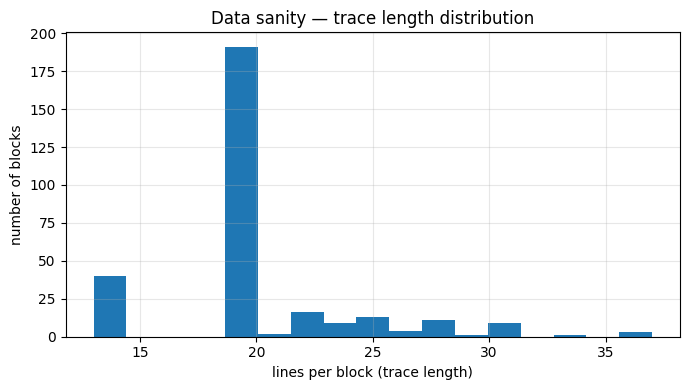

In [ ]:
import matplotlib.pyplot as plt
sizes = work['true_block'].value_counts().values
plt.figure(figsize=(7,4)); plt.hist(sizes, bins=min(40, len(set(sizes))))
plt.xlabel('lines per block (trace length)'); plt.ylabel('number of blocks')
plt.title('Data sanity — trace length distribution'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### Leakage

In [ ]:
adj_same = float(np.mean(work['true_block'].values[1:] == work['true_block'].values[:-1]))
print(f'Fraction of adjacent rows sharing the same block: {adj_same:.3f}')
if adj_same > 0.5:
    print('WARNING: the log looks block-sorted. The temporal feature may inflate results.')
    print('         Report TIME_WEIGHT=0 as a baseline and/or shuffle before clustering.')
else:
    print('OK: adjacency is low, temporal proximity is not a trivial giveaway.')

Fraction of adjacent rows sharing the same block: 0.721
         Report TIME_WEIGHT=0 as a baseline and/or shuffle before clustering.


## Preprocessing

In [ ]:
def clean(text, mode=CLEAN_MODE):
    text = str(text)
    text = re.sub(r'blk_-?\d+(_\d+)?', ' ', text)      # remove the ground-truth id (+ genstamp) — prevents leakage
    text = re.sub(r'^\d{6}\s+\d{6}\s+\d+\s*', ' ', text)  # strip the leading timestamp so the
    text = re.sub(r'\d{4}-\d{2}-\d{2}[ ,:\d]*', ' ', text)  # TIME_WEIGHT=0 baseline is truly meaning-only
    if mode == 'aggressive':
        text = re.sub(r'/[\w./:-]+', ' ', text)         # paths / ip:port
        text = re.sub(r'\d+', ' ', text)                # remaining numbers
        text = re.sub(r'[^A-Za-z\s]', ' ', text)        # punctuation
    return re.sub(r'\s+', ' ', text).strip().lower()

work['clean'] = work['message'].apply(clean)
assert not work['clean'].str.contains('blk_').any(), 'Block id leaked into the cleaned text!'
display(work[['message','clean','true_block']].head(8))

,message,clean,true_block
0,081109 204238 34 INFO dfs.FSNamesystem: BLOCK*...,info dfs.fsnamesystem: block* namesystem.alloc...,blk_-1121858602935306008
1,081109 204238 417 INFO dfs.DataNode$DataXceive...,info dfs.datanode$dataxceiver: receiving block...,blk_-1121858602935306008
2,081109 204238 428 INFO dfs.DataNode$DataXceive...,info dfs.datanode$dataxceiver: receiving block...,blk_-1121858602935306008
3,081109 204239 413 INFO dfs.DataNode$DataXceive...,info dfs.datanode$dataxceiver: receiving block...,blk_-1121858602935306008
4,081109 204328 26 INFO dfs.FSNamesystem: BLOCK*...,info dfs.fsnamesystem: block* namesystem.addst...,blk_-1121858602935306008
5,081109 204328 27 INFO dfs.FSNamesystem: BLOCK*...,info dfs.fsnamesystem: block* namesystem.addst...,blk_-1121858602935306008
6,081109 204328 31 INFO dfs.FSNamesystem: BLOCK*...,info dfs.fsnamesystem: block* namesystem.addst...,blk_-1121858602935306008
7,081109 204328 414 INFO dfs.DataNode$PacketResp...,info dfs.datanode$packetresponder: packetrespo...,blk_-1121858602935306008


## Embedding

In [ ]:
import numpy as np, hashlib, os
from gensim.models import Word2Vec

W2V_DIM = 100   # standard Word2Vec size; must be >= PCA_DIM (50)

texts  = work['clean'].tolist()
tokens = [t.split() for t in texts]          # simple whitespace tokenisation
print('Token example:', tokens[0][:8])

key   = hashlib.md5((CLEAN_MODE+'|'+'|'.join(texts)).encode()).hexdigest()[:10]
cache = f'emb_w2v_{key}.npy'
if os.path.exists(cache):
    X = np.load(cache); print('Loaded cached embeddings:', X.shape)
else:
    w2v = Word2Vec(sentences=tokens, vector_size=W2V_DIM, window=5,
                   min_count=1, sg=1, workers=4, epochs=10, seed=SEED)
    def embed(toks):
        vs = [w2v.wv[w] for w in toks if w in w2v.wv]
        return np.mean(vs, axis=0) if vs else np.zeros(W2V_DIM, dtype=np.float32)
    X = np.vstack([embed(t) for t in tokens]).astype(np.float32)
    np.save(cache, X); print('Embeddings:', X.shape, '(cached)')

Token example: ['info', 'dfs.fsnamesystem:', 'block*', 'namesystem.allocateblock:', '/user/root/rand/_temporary/_task_200811092030_0001_m_000209_0/part-00209.']
Embeddings: (5967, 100) (cached)


## Fusion

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize

def build_features(X, t, time_weight=TIME_WEIGHT, pca_dim=PCA_DIM, seed=SEED):
    Xr = PCA(n_components=min(pca_dim, X.shape[1]), random_state=seed).fit_transform(X)
    Xr = normalize(StandardScaler().fit_transform(Xr))   # unit-norm SEMANTICS ONLY (cosine-like)
    ts = np.asarray(t, float).reshape(-1, 1)
    ts = (ts - ts.min()) / TIME_UNIT                     # real time, in TIME_UNIT-second units
    return np.hstack([Xr, time_weight * ts])             # NO final normalize — it would erase time

feats_preview = build_features(X, work['t'].values)
print('Fused feature shape:', feats_preview.shape, '(', PCA_DIM, 'semantic +1 time )')

Fused feature shape: (5967, 51) ( 50 semantic +1 time )


### Eps

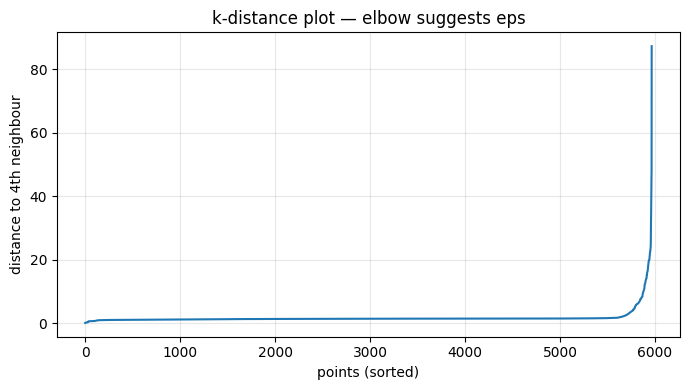

Suggested eps around the 50th-90th percentile: 1.374 to 1.517


In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
d, _ = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(feats_preview).kneighbors(feats_preview)
kd = np.sort(d[:, -1])
plt.figure(figsize=(7,4)); plt.plot(kd)
plt.xlabel('points (sorted)'); plt.ylabel(f'distance to {MIN_SAMPLES}th neighbour')
plt.title('k-distance plot — elbow suggests eps'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print('Suggested eps around the 50th-90th percentile:',
      round(np.percentile(kd,50),3), 'to', round(np.percentile(kd,90),3))

## Clustering

In [ ]:
import time
from sklearn.cluster import DBSCAN
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_completeness_v_measure, silhouette_score)
from sklearn.metrics.cluster import pair_confusion_matrix

def _singleton_noise(labels):
    # give each noise point its own unique cluster id (fair: unassigned != one big group)
    lab = labels.copy()
    idx = np.where(lab == -1)[0]
    if len(idx):
        start = lab.max() + 1
        lab[idx] = np.arange(start, start + len(idx))
    return lab

def run_pipeline(X, t, true_block, eps=EPS, min_samples=MIN_SAMPLES,
                 time_weight=TIME_WEIGHT, pca_dim=PCA_DIM, seed=SEED, verbose=False):
    y_true = pd.factorize(true_block)[0]
    t0 = time.time()
    feats = build_features(X, t, time_weight, pca_dim, seed)
    labels = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean').fit_predict(feats)
    runtime = time.time() - t0

    lab_eval = _singleton_noise(labels)          # noise -> singleton traces
    r = {'eps':eps, 'min_samples':min_samples, 'time_weight':time_weight,
         'n_clusters': int(len(set(labels)) - (1 if -1 in labels else 0)),
         'n_true_blocks': int(len(set(y_true))),
         'noise_frac': float((labels==-1).mean()),
         'runtime_s': round(runtime,2)}

    # headline reconstruction metrics (all logs, noise as singletons)
    r['ARI'] = adjusted_rand_score(y_true, lab_eval)
    r['NMI'] = normalized_mutual_info_score(y_true, lab_eval)
    h,c,v = homogeneity_completeness_v_measure(y_true, lab_eval)
    r['homogeneity'], r['completeness'], r['v_measure'] = h, c, v

    # pairwise confusion matrix -> precision / recall / f1
    (tn,fp),(fn,tp) = pair_confusion_matrix(y_true, lab_eval)
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    r.update(pair_TP=int(tp), pair_FP=int(fp), pair_FN=int(fn), pair_TN=int(tn),
             pair_precision=prec, pair_recall=rec, pair_f1=f1)

    # supporting internal metrics (clustered points only)
    m = labels != -1
    if m.sum() > 1 and len(set(labels[m])) > 1:
        try: r['silhouette'] = float(silhouette_score(feats[m], labels[m]))
        except Exception: r['silhouette'] = float('nan')
    else:
        r['silhouette'] = float('nan')

    if verbose:
        for k,val in r.items(): print(f'  {k:16}: {val}')
    return labels, r

labels, metrics = run_pipeline(X, work['t'].values, work['true_block'], verbose=True)
work['cluster'] = labels
work['virtual_trace_id'] = ['NO_TRACE' if c==-1 else f'VTRACE_{c:05d}' for c in labels]

  eps             : 1.5
  min_samples     : 4
  time_weight     : 2.0
  n_clusters      : 418
  n_true_blocks   : 300
  noise_frac      : 0.0685436567789509
  runtime_s       : 0.29
  ARI             : 0.2085968963050943
  NMI             : 0.7893329868731759
  homogeneity     : 0.796567405831683
  completeness    : 0.7822287911016612
  v_measure       : 0.789332986873176
  pair_TP         : 37494
  pair_FP         : 197696
  pair_FN         : 80870
  pair_TN         : 35283062
  pair_precision  : 0.15942004336919086
  pair_recall     : 0.31676861207799667
  pair_f1         : 0.21209772764556475
  silhouette      : 0.45580166305676234


### Results

In [ ]:
print('Pairwise confusion matrix (line-pairs):')
print(f"                same-cluster   diff-cluster")
print(f"  same-block      TP={metrics['pair_TP']:>10}   FN={metrics['pair_FN']:>10}")
print(f"  diff-block      FP={metrics['pair_FP']:>10}   TN={metrics['pair_TN']:>10}")
print(f"\n  Pairwise precision {metrics['pair_precision']:.4f} | recall {metrics['pair_recall']:.4f} | F1 {metrics['pair_f1']:.4f}")
print(f"  ARI {metrics['ARI']:.4f} | NMI {metrics['NMI']:.4f} | V-measure {metrics['v_measure']:.4f}")
print(f"  clusters found {metrics['n_clusters']} vs true blocks {metrics['n_true_blocks']} | noise {metrics['noise_frac']:.1%}")

Pairwise confusion matrix (line-pairs):
                same-cluster   diff-cluster
  same-block      TP=     37494   FN=     80870
  diff-block      FP=    197696   TN=  35283062

  Pairwise precision 0.1594 | recall 0.3168 | F1 0.2121
  ARI 0.2086 | NMI 0.7893 | V-measure 0.7893
  clusters found 418 vs true blocks 300 | noise 6.9%


In [ ]:
# Peek at reconstructed traces — one good example, plus honest purity stats
cl = work[work['cluster'] != -1]
purity = cl.groupby('cluster')['true_block'].nunique()
pure = purity[purity == 1]
print(f'Clusters found: {purity.shape[0]} | perfectly pure (1 true block): {len(pure)} '
      f'({len(pure)/max(purity.shape[0],1):.0%})')

# best example: the largest perfectly-pure cluster
if len(pure):
    best = cl[cl['cluster'].isin(pure.index)]['cluster'].value_counts().index[0]
    b = work[work.cluster == best]
    print(f"\nExample well-reconstructed trace VTRACE_{best:05d} "
          f"({len(b)} lines, true block: {b['true_block'].iloc[0]}):")
    for m in b['message'].head(8):
        print('  -', m[:140])

# worst example: the most over-merged cluster (be honest about the failure mode)
worst = purity.idxmax()
w = work[work.cluster == worst]
print(f"\nMost over-merged cluster VTRACE_{worst:05d} mixes {purity.max()} true blocks "
      f"({len(w)} lines) — typically simultaneous delete storms with identical text.")
for m in w['message'].head(3):
    print('  -', m[:140])

Clusters found: 418 | perfectly pure (1 true block): 293 (70%)

Example well-reconstructed trace VTRACE_00130 (15 lines, true block: blk_379492178713695394):
  - 081110 125809 11364 WARN dfs.DataNode$DataXceiver: 10.250.15.198:50010:Got exception while serving blk_379492178713695394 to /10.251.123.1:
  - 081110 125813 11365 WARN dfs.DataNode$DataXceiver: 10.250.15.198:50010:Got exception while serving blk_379492178713695394 to /10.251.39.242:
  - 081110 125818 11610 WARN dfs.DataNode$DataXceiver: 10.250.14.38:50010:Got exception while serving blk_379492178713695394 to /10.251.42.16:
  - 081110 125821 11608 INFO dfs.DataNode$DataXceiver: 10.250.14.38:50010 Served block blk_379492178713695394 to /10.250.14.38
  - 081110 125853 11642 WARN dfs.DataNode$DataXceiver: 10.251.195.70:50010:Got exception while serving blk_379492178713695394 to /10.250.7.96:
  - 081110 125857 11613 WARN dfs.DataNode$DataXceiver: 10.250.14.38:50010:Got exception while serving blk_379492178713695394 to /10.250.7.96

## Visualisation

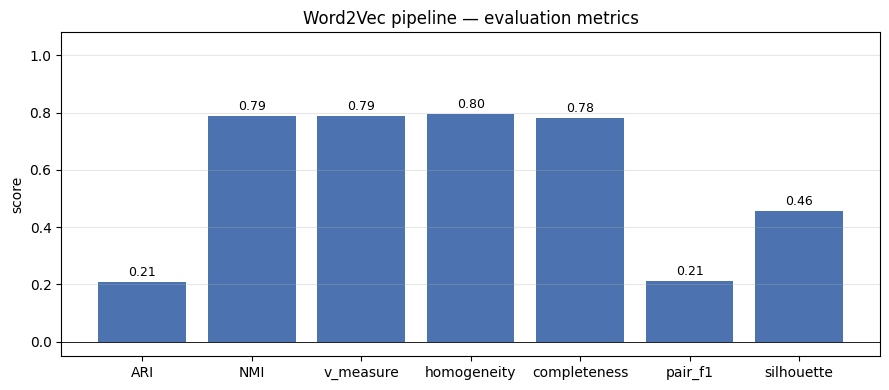

In [ ]:
import matplotlib.pyplot as plt, numpy as np
# (1) metric summary bar chart
keys = ['ARI','NMI','v_measure','homogeneity','completeness','pair_f1','silhouette']
vals = [metrics.get(k, np.nan) for k in keys]
plt.figure(figsize=(9,4))
bars = plt.bar(keys, vals, color='#4C72B0')
for b,v in zip(bars, vals):
    if v==v: plt.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}', ha='center', fontsize=9)
lo = min(-0.05, np.nanmin(vals)-0.05)
plt.ylim(lo, 1.08); plt.axhline(0, color='k', lw=.6); plt.ylabel('score')
plt.title('Word2Vec pipeline — evaluation metrics'); plt.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

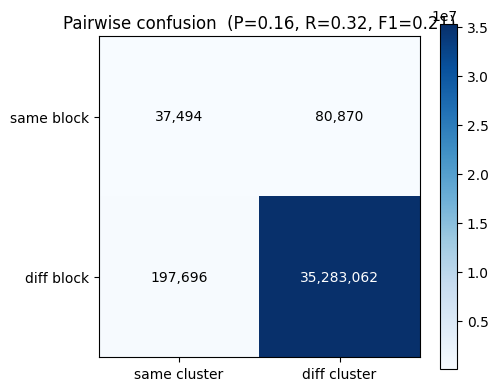

In [ ]:
# (2) pairwise confusion matrix heatmap
cm = np.array([[metrics['pair_TP'], metrics['pair_FN']],
               [metrics['pair_FP'], metrics['pair_TN']]], float)
plt.figure(figsize=(5.2,4.2))
plt.imshow(cm, cmap='Blues')
plt.xticks([0,1], ['same cluster','diff cluster']); plt.yticks([0,1], ['same block','diff block'])
mx = cm.max() if cm.max()>0 else 1
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{int(cm[i,j]):,}', ha='center', va='center',
                 color='white' if cm[i,j] > mx/2 else 'black')
plt.title(f"Pairwise confusion  (P={metrics['pair_precision']:.2f}, R={metrics['pair_recall']:.2f}, F1={metrics['pair_f1']:.2f})")
plt.colorbar(); plt.tight_layout(); plt.show()

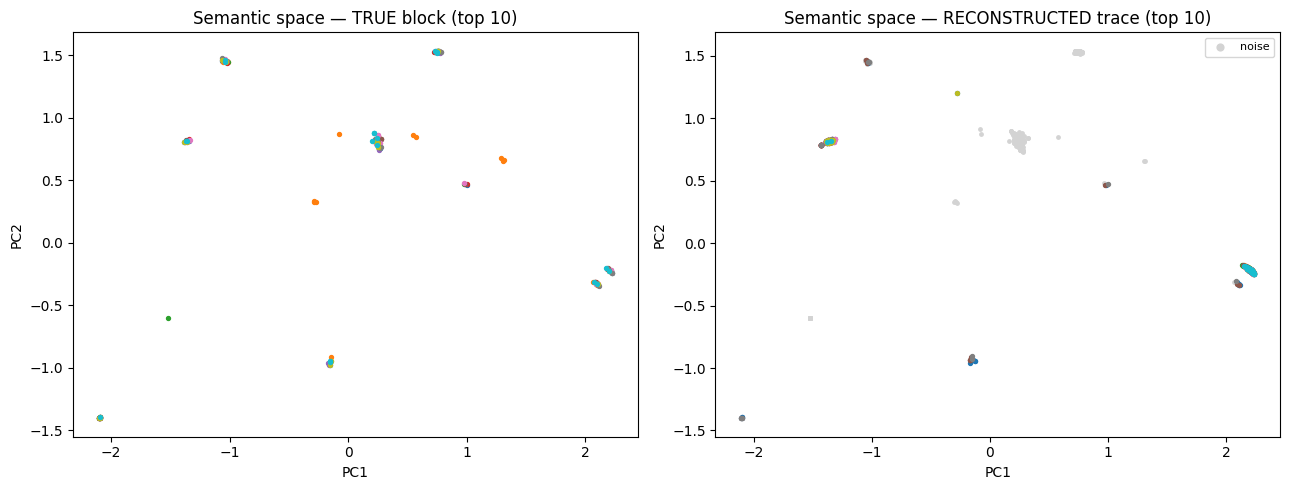

If the left and right colourings line up, the reconstruction matched the true traces.


In [ ]:
# (3) 2D semantic space: TRUE blocks vs RECONSTRUCTED traces
from sklearn.decomposition import PCA
emb2 = PCA(n_components=2, random_state=SEED).fit_transform(X)
sub = np.arange(len(emb2))
if len(sub) > 4000:
    sub = np.random.default_rng(SEED).choice(sub, 4000, replace=False)
E, TB, CL = emb2[sub], work['true_block'].values[sub], labels[sub]
fig, ax = plt.subplots(1, 2, figsize=(13,5))
for b in pd.Series(TB).value_counts().index[:10]:
    m = TB==b; ax[0].scatter(E[m,0], E[m,1], s=8)
ax[0].set_title('Semantic space — TRUE block (top 10)')
ax[1].scatter(E[CL==-1,0], E[CL==-1,1], s=6, c='lightgrey', label='noise')
for c in pd.Series(CL[CL!=-1]).value_counts().index[:10]:
    m = CL==c; ax[1].scatter(E[m,0], E[m,1], s=8)
ax[1].set_title('Semantic space — RECONSTRUCTED trace (top 10)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
ax[1].legend(fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()
print('If the left and right colourings line up, the reconstruction matched the true traces.')

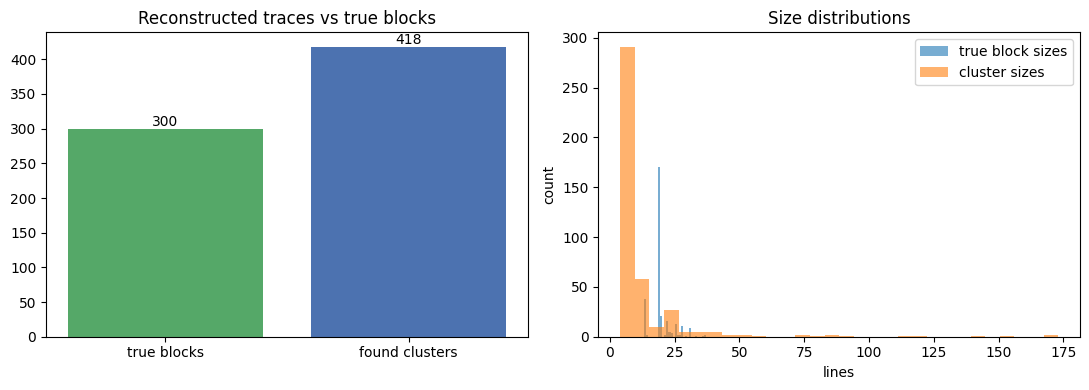

Noise (unassigned) logs: 6.9%


In [ ]:
# (4) clusters found vs true blocks + noise
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].bar(['true blocks','found clusters'],
          [metrics['n_true_blocks'], metrics['n_clusters']], color=['#55A868','#4C72B0'])
ax[0].set_title('Reconstructed traces vs true blocks')
for i,v in enumerate([metrics['n_true_blocks'], metrics['n_clusters']]):
    ax[0].text(i, v, str(v), ha='center', va='bottom')
cl_sizes = pd.Series(labels[labels!=-1]).value_counts().values
tb_sizes = work['true_block'].value_counts().values
ax[1].hist(tb_sizes, bins=30, alpha=.6, label='true block sizes')
if len(cl_sizes): ax[1].hist(cl_sizes, bins=30, alpha=.6, label='cluster sizes')
ax[1].set_xlabel('lines'); ax[1].set_ylabel('count'); ax[1].set_title('Size distributions'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Noise (unassigned) logs: {metrics['noise_frac']:.1%}")

## Save

In [ ]:
out = work[['message','t','true_block','virtual_trace_id']]
out.to_csv('reconstructed_traces_word2vec.csv', index=False)
print('Saved reconstructed_traces_word2vec.csv', out.shape)
try:
    from google.colab import files; files.download('reconstructed_traces_word2vec.csv')
except Exception: pass

Saved reconstructed_traces_word2vec.csv (5967, 4)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Sweep

In [ ]:
rows = []
for eps in EPS_GRID:
    for tw in TIME_WEIGHT_GRID:
        _, r = run_pipeline(X, work['t'].values, work['true_block'], eps=eps, time_weight=tw)
        rows.append(r)
sweep = pd.DataFrame(rows)
cols = ['eps','time_weight','n_clusters','noise_frac','ARI','NMI','pair_f1','silhouette']
display(sweep[cols].round(4))
best = sweep.loc[sweep['ARI'].idxmax()]
print(f"Best ARI = {best['ARI']:.4f} at eps={best['eps']}, time_weight={best['time_weight']}")

,eps,time_weight,n_clusters,noise_frac,ARI,NMI,pair_f1,silhouette
0,1.4,0.0,2,0.0000,-0.0000,0.0061,0.0066,0.0235
1,1.4,1.0,287,0.1810,0.1616,0.7684,0.1656,0.4897
2,1.4,2.0,392,0.2586,0.1338,0.7648,0.1373,0.4712
3,1.4,3.0,419,0.2899,0.1208,0.7661,0.1243,0.5245
4,1.4,5.0,453,0.3228,0.1231,0.7738,0.1262,0.5922
5,1.5,0.0,1,0.0000,0.0000,0.0000,0.0066,NaN
6,1.5,1.0,244,0.0511,0.2042,0.7820,0.2082,0.5163
7,1.5,2.0,418,0.0685,0.2086,0.7893,0.2121,0.4558
8,1.5,3.0,491,0.0820,0.1963,0.7902,0.1996,0.4760
9,1.5,5.0,538,0.0982,0.1926,0.7955,0.1958,0.5642


Best ARI = 0.2090 at eps=1.8, time_weight=2.0


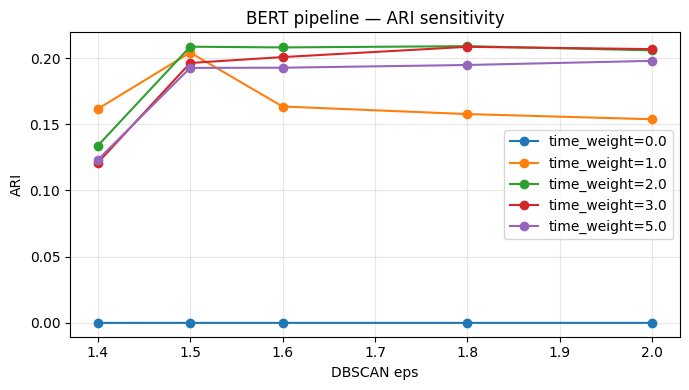

In [ ]:
# ARI vs eps, one line per time_weight
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
for tw in TIME_WEIGHT_GRID:
    s = sweep[sweep.time_weight==tw].sort_values('eps')
    plt.plot(s['eps'], s['ARI'], marker='o', label=f'time_weight={tw}')
plt.xlabel('DBSCAN eps'); plt.ylabel('ARI'); plt.title('BERT pipeline — ARI sensitivity')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

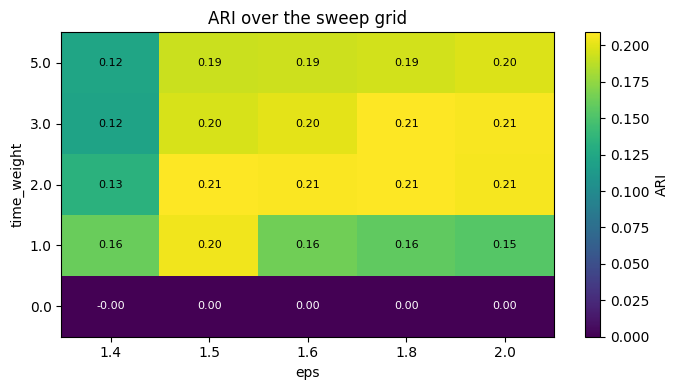

In [ ]:
# ARI heatmap over the eps x time_weight grid
piv = sweep.pivot(index='time_weight', columns='eps', values='ARI')
plt.figure(figsize=(7,4))
plt.imshow(piv.values, aspect='auto', cmap='viridis', origin='lower')
plt.xticks(range(len(piv.columns)), piv.columns); plt.yticks(range(len(piv.index)), piv.index)
plt.xlabel('eps'); plt.ylabel('time_weight'); plt.title('ARI over the sweep grid')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        plt.text(j, i, f'{piv.values[i,j]:.2f}', ha='center', va='center',
                 color='white' if piv.values[i,j] < np.nanmax(piv.values)/2 else 'black', fontsize=8)
plt.colorbar(label='ARI'); plt.tight_layout(); plt.show()

## Ablation

In [ ]:
# Ablation — time vs meaning, eps tuned PER configuration (fair geometry for each space)
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.cluster import pair_confusion_matrix
np.random.seed(SEED)

# same PCA -> StandardScaler -> L2-normalise treatment as build_features, split by mode
def build_mode(X_, t, mode, time_weight=TIME_WEIGHT, pca_dim=PCA_DIM, seed=SEED):
    ts = ((np.asarray(t, float) - np.min(t)) / TIME_UNIT).reshape(-1, 1)   # real time, minutes
    if mode == 'time-only':
        return ts
    Xr = PCA(n_components=min(pca_dim, X_.shape[1]), random_state=seed).fit_transform(X_)
    sem = normalize(StandardScaler().fit_transform(Xr))                    # unit-norm semantics
    if mode == 'meaning-only':
        return sem
    return np.hstack([sem, time_weight * ts])                              # combined = the pipeline

# identical metric definitions to run_pipeline (noise -> singleton clusters)
def eval_config(feats, y_true, eps):
    lab = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(feats)
    le  = _singleton_noise(lab)
    (tn, fp), (fn, tp) = pair_confusion_matrix(y_true, le)
    p = tp/(tp+fp) if (tp+fp) else 0.0
    r = tp/(tp+fn) if (tp+fn) else 0.0
    return {'ARI': adjusted_rand_score(y_true, le),
            'NMI': normalized_mutual_info_score(y_true, le),
            'pair_f1': 2*p*r/(p+r) if (p+r) else 0.0,
            'n_clusters': int(len(set(lab)) - (1 if -1 in lab else 0)),
            'noise_frac': float((lab == -1).mean())}

# per-mode eps grids: each feature space has its own geometry, so one fixed eps is unfair
EPS_GRIDS = {
    'meaning-only': np.round(np.arange(0.20, 1.62, 0.05), 2),                 # unit-norm space (max dist 2)
    'time-only':    np.round(np.concatenate([np.arange(0.20, 1.62, 0.05),     # minutes...
                                             [2.0, 3.0, 5.0, 10.0]]), 2),     # ...plus coarse tail
    'combined':     np.round(np.arange(0.20, 2.02, 0.05), 2),
}

def tune(X_, t, y_true, model_name):
    rows = []
    for mode, grid in EPS_GRIDS.items():
        best = None
        for eps in grid:
            m = eval_config(build_mode(X_, t, mode), y_true, float(eps))
            if best is None or m['ARI'] > best['ARI']:
                best = {'model': model_name, 'mode': mode, 'best_eps': float(eps), **m}
        rows.append(best)
        print(f"  {model_name:9s} {mode:13s} best_eps={best['best_eps']:<5} ARI={best['ARI']:.4f}")
    return rows

y_true = pd.factorize(work['true_block'])[0]
REPRESENTATIONS = {'Word2Vec': X}   # this notebook's embeddings

In [ ]:
# OPTIONAL — load the OTHER representation's cached embeddings for the side-by-side
# (produced by the BERT notebook on this same runtime & sample; same cache key = same data)
other_cache = f'emb_bert_{key}.npy'
if os.path.exists(other_cache):
    REPRESENTATIONS['BERT'] = np.load(other_cache)
    print('Loaded', other_cache, REPRESENTATIONS['BERT'].shape)
else:
    print(f'{other_cache} not found — run the BERT notebook on this runtime to enable the side-by-side.')

emb_bert_6747d0ec00.npy not found — run the BERT notebook on this runtime to enable the side-by-side.


  Word2Vec  meaning-only  best_eps=0.85  ARI=0.0112
  Word2Vec  time-only     best_eps=0.65  ARI=0.2076
  Word2Vec  combined      best_eps=1.55  ARI=0.2134


,model,mode,best_eps,ARI,NMI,pair_f1,n_clusters,noise_frac
0,Word2Vec,meaning-only,0.85,0.0112,0.5443,0.0164,381,0.1175
1,Word2Vec,time-only,0.65,0.2076,0.7900,0.2115,324,0.0514
2,Word2Vec,combined,1.55,0.2134,0.7893,0.2169,403,0.0630


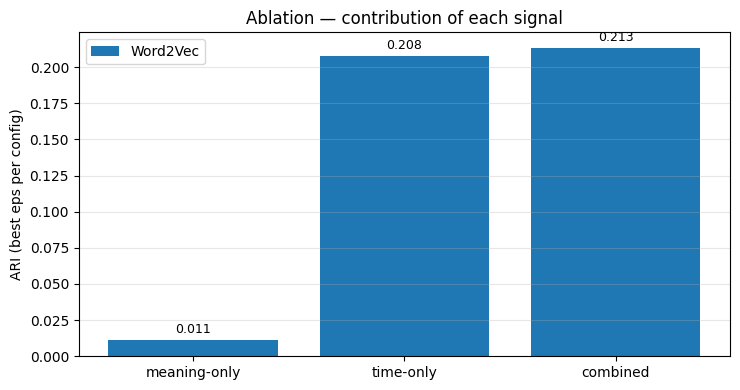

[Word2Vec] meaning-only ARI=0.0112 | time-only ARI=0.2076 | combined ARI=0.2134
  -> meaning-only is ABOVE chance (~0).
  -> combined does NOT meaningfully beat time-only (+0.0058 ARI).
  -> temporal proximity dominates on template-heavy HDFS; the representation is not the bottleneck.


In [ ]:
# run the ablation for every loaded representation
rows = []
for name, X_ in REPRESENTATIONS.items():
    rows += tune(X_, work['t'].values, y_true, name)
ablation = pd.DataFrame(rows)[['model','mode','best_eps','ARI','NMI','pair_f1','n_clusters','noise_frac']].round(4)
display(ablation)

# grouped bar chart — ARI per mode, models side by side
import matplotlib.pyplot as plt
modes  = ['meaning-only', 'time-only', 'combined']
models = list(REPRESENTATIONS.keys())
xpos   = np.arange(len(modes)); w = 0.8 / len(models)
plt.figure(figsize=(7.5, 4))
for j, mdl in enumerate(models):
    vals = [float(ablation[(ablation.model == mdl) & (ablation['mode'] == m)]['ARI'].iloc[0]) for m in modes]
    bars = plt.bar(xpos + j*w, vals, w, label=mdl)
    for b, v in zip(bars, vals):
        plt.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.xticks(xpos + w*(len(models)-1)/2, modes); plt.ylabel('ARI (best eps per config)')
plt.title('Ablation — contribution of each signal'); plt.legend(); plt.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()

# plain-English verdict, computed from the numbers
CHANCE = 0.01
for mdl in models:
    g = {m: float(ablation[(ablation.model == mdl) & (ablation['mode'] == m)]['ARI'].iloc[0]) for m in modes}
    gain = g['combined'] - g['time-only']
    print(f"[{mdl}] meaning-only ARI={g['meaning-only']:.4f} | time-only ARI={g['time-only']:.4f} | combined ARI={g['combined']:.4f}")
    print(f"  -> meaning-only is {'ABOVE' if g['meaning-only'] > CHANCE else 'NOT above'} chance (~0).")
    print(f"  -> combined {'BEATS' if gain > 0.02 else 'does NOT meaningfully beat'} time-only ({gain:+.4f} ARI).")
    if gain > 0.02:
        print('  -> semantics adds measurable trace-separating signal on top of temporal proximity.')
    else:
        print('  -> temporal proximity dominates on template-heavy HDFS; the representation is not the bottleneck.')
if len(models) == 2:
    a = {m: float(ablation[(ablation.model == models[0]) & (ablation['mode'] == m)]['ARI'].iloc[0]) for m in modes}
    b = {m: float(ablation[(ablation.model == models[1]) & (ablation['mode'] == m)]['ARI'].iloc[0]) for m in modes}
    d = max(abs(a[m] - b[m]) for m in modes)
    print(f"[{models[0]} vs {models[1]}] max ARI difference across modes = {d:.4f} -> "
          + ('the representations DIFFER meaningfully.' if d > 0.02 else 'the two representations perform equivalently.'))